# **Day 49: Principal Component Analysis (PCA) and SVD**
*Module 8 - Unsupervised Learning*

PCA finds new axes (principal components) that capture the **maximum variance** with the **fewest dimensions**. It is used for compression, denoising, visualisation, removing multicollinearity before regression, speeding up models, and in remote sensing for hyperspectral data reduction and **change detection**.

> PCA finds new axes along which the data varies most and lets us keep only the first few. This reduces dimensions while keeping most of the information. SVD is the matrix tool behind it.
>
> *Example:* Hundreds of strongly correlated hyperspectral bands can often be summarised by 5-10 principal components with little information loss.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
rng = np.random.default_rng(49)

## **1. Intuition in 2-D**

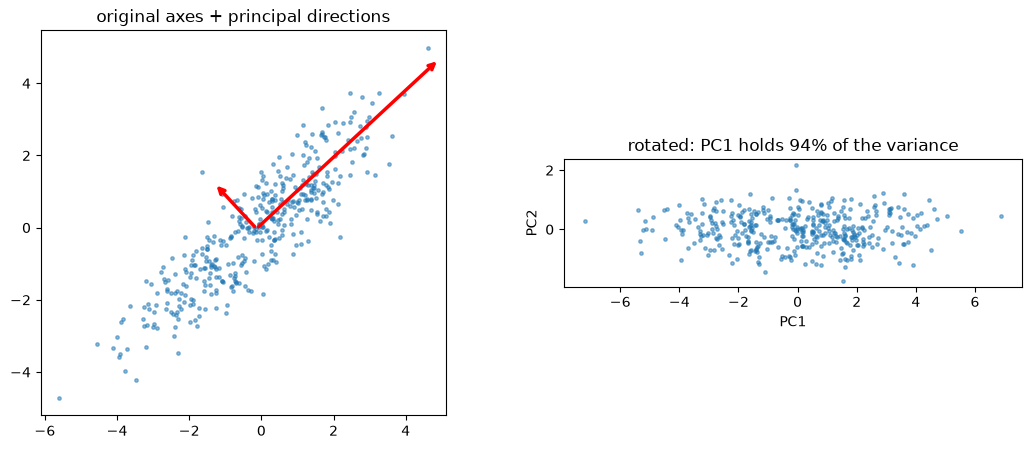

In [2]:
X2 = rng.multivariate_normal([0, 0], [[3, 2.4], [2.4, 2.5]], 400)
pca2 = PCA(2).fit(X2)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(*X2.T, s=6, alpha=0.5)
for length, vec in zip(pca2.explained_variance_, pca2.components_):
    axes[0].annotate("", pca2.mean_ + vec * 3 * np.sqrt(length), pca2.mean_, arrowprops=dict(arrowstyle="->", lw=2.5, color="r"))
axes[0].set(title="original axes + principal directions", aspect="equal")
Z2 = pca2.transform(X2)
axes[1].scatter(*Z2.T, s=6, alpha=0.5); axes[1].set(title=f"rotated: PC1 holds {pca2.explained_variance_ratio_[0]:.0%} of the variance", xlabel="PC1", ylabel="PC2", aspect="equal")
plt.show()

## **2. PCA From Scratch: Two Equivalent Routes**
Centre the data, $X_c = X - \bar{\mathbf x}$.
- **Eigen route**: the principal directions are the eigenvectors of the covariance $C = \frac{1}{n-1}X_c^\top X_c$; the eigenvalues are the variances along them.
- **SVD route** (numerically better): $X_c = U\Sigma V^\top$. The rows of $V^\top$ are the directions; variances are $\sigma_i^2/(n-1)$; the scores are $U\Sigma$.

In [3]:
from sklearn.datasets import load_wine
Xw, yw = load_wine(return_X_y=True); names = load_wine().feature_names
Xs = StandardScaler().fit_transform(Xw)

C = np.cov(Xs.T); evals, evecs = np.linalg.eigh(C); order = evals.argsort()[::-1]; evals, evecs = evals[order], evecs[:, order]
U, S, Vt = np.linalg.svd(Xs - Xs.mean(0), full_matrices=False)
sk = PCA().fit(Xs)
print("variances (eigen):", evals[:4].round(4))
print("variances (SVD)  :", (S ** 2 / (len(Xs) - 1))[:4].round(4))
print("variances (sklearn):", sk.explained_variance_[:4].round(4))
print("same directions (up to sign):", np.allclose(np.abs(evecs[:, :4].T), np.abs(sk.components_[:4]), atol=1e-6))

variances (eigen): [4.7324 2.5111 1.4542 0.9242]
variances (SVD)  : [4.7324 2.5111 1.4542 0.9242]
variances (sklearn): [4.7324 2.5111 1.4542 0.9242]
same directions (up to sign): True


## **3. How Many Components?**
- Keep components explaining e.g. 90-95% of the variance.
- Look for the **elbow** of the scree plot.
- Kaiser rule (standardised data): eigenvalue > 1.
- Best for prediction: choose by **cross-validation** of the downstream model.

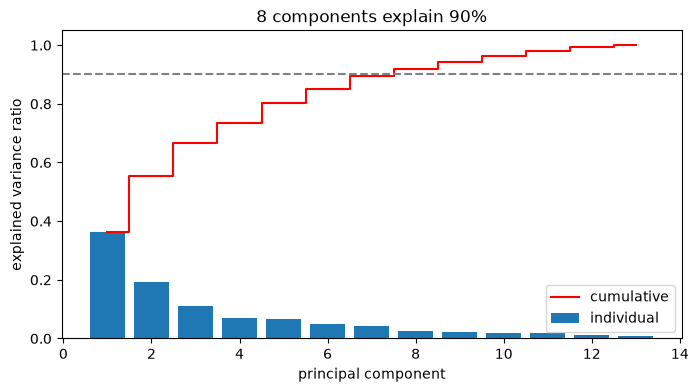

PCA(n_components=0.9) keeps 8 components


In [4]:
cum = np.cumsum(sk.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 14), sk.explained_variance_ratio_, label="individual"); ax.step(range(1, 14), cum, where="mid", c="r", label="cumulative")
ax.axhline(0.9, ls="--", c="grey"); ax.set(xlabel="principal component", ylabel="explained variance ratio", title=f"{np.searchsorted(cum, 0.9) + 1} components explain 90%")
ax.legend(); plt.show()
print("PCA(n_components=0.9) keeps", PCA(0.9).fit(Xs).n_components_, "components")

## **4. Loadings and the Biplot**
**Loadings** (components x sqrt(variance)) are the correlations between original features and components. A **biplot** shows samples (scores) and features (arrows) together.

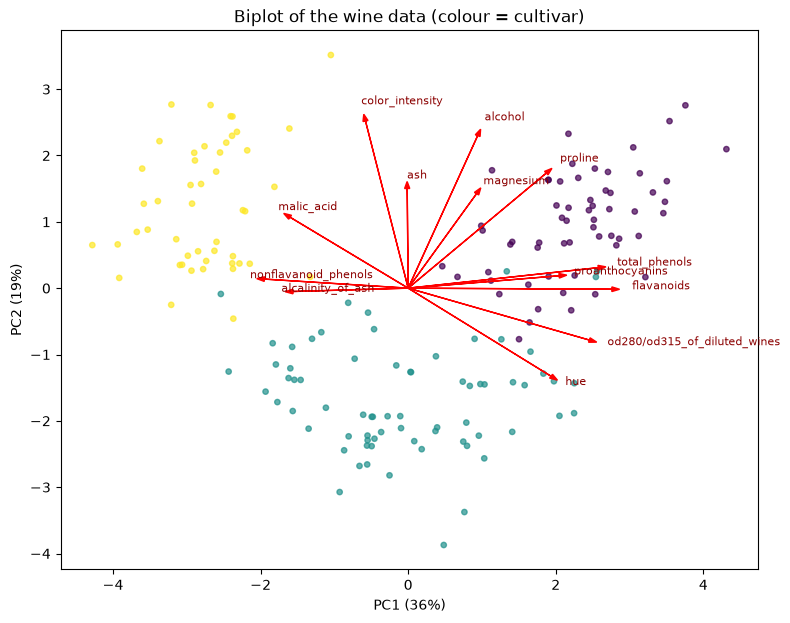

In [5]:
Z = sk.transform(Xs)[:, :2]
load = sk.components_[:2].T * np.sqrt(sk.explained_variance_[:2])
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(*Z.T, c=yw, cmap="viridis", s=15, alpha=0.7)
for i, nme in enumerate(names):
    ax.arrow(0, 0, load[i, 0] * 3, load[i, 1] * 3, color="r", head_width=0.07)
    ax.text(load[i, 0] * 3.3, load[i, 1] * 3.3, nme, fontsize=8, color="darkred")
ax.set(xlabel=f"PC1 ({sk.explained_variance_ratio_[0]:.0%})", ylabel=f"PC2 ({sk.explained_variance_ratio_[1]:.0%})", title="Biplot of the wine data (colour = cultivar)")
plt.show()

## **5. Reconstruction and Denoising**
Project to $k$ components and back: $\hat X = Z_kV_k^\top + \bar{\mathbf x}$. Noise spread over all dimensions is largely discarded.

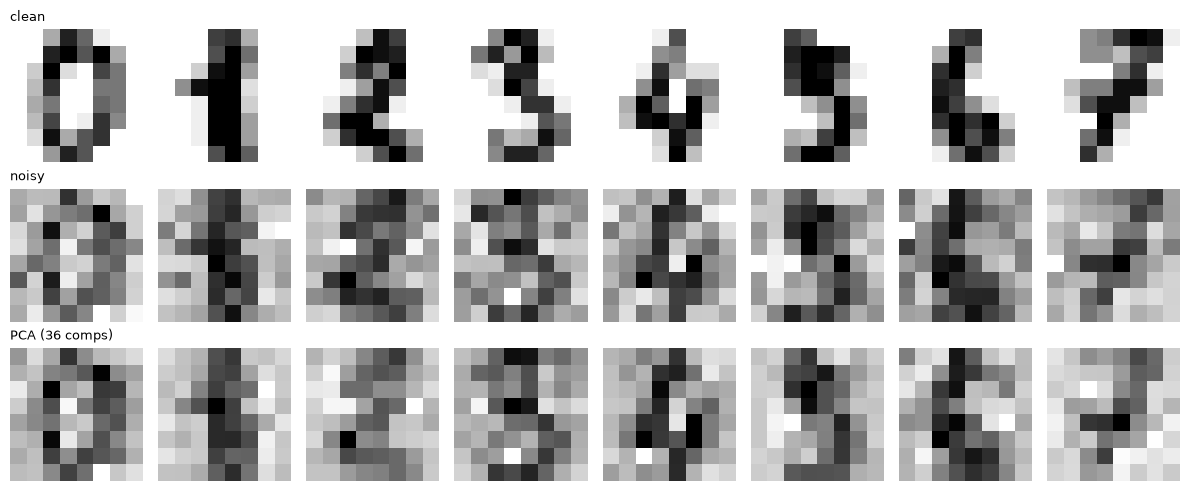

In [6]:
from sklearn.datasets import load_digits
Xd, yd = load_digits(return_X_y=True)
noisy = Xd + rng.normal(0, 4, Xd.shape)
pca_d = PCA(0.80).fit(noisy)
denoised = pca_d.inverse_transform(pca_d.transform(noisy))
fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for j in range(8):
    for i, (img, lab) in enumerate([(Xd, "clean"), (noisy, "noisy"), (denoised, f"PCA ({pca_d.n_components_} comps)")]):
        axes[i, j].imshow(img[j].reshape(8, 8), cmap="gray_r"); axes[i, j].axis("off")
        if j == 0: axes[i, j].set_title(lab, fontsize=9, loc="left")
plt.tight_layout(); plt.show()

## **6. Principal Component Regression and PCA in Pipelines**
With many correlated features (spectra, Day 24), regress on a few components. Choose the number of components by CV, inside a pipeline.

In [7]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.cross_decomposition import PLSRegression
p = 150
idx = np.arange(p); corr = 0.97 ** np.abs(np.subtract.outer(idx, idx))
Xh = rng.normal(size=(120, p)) @ np.linalg.cholesky(corr).T
yh = Xh[:, 40:50].mean(1) * 3 - Xh[:, 100:105].mean(1) * 2 + rng.normal(0, 0.5, 120)
for k in [2, 5, 10, 20, 40]:
    pcr = make_pipeline(StandardScaler(), PCA(k), LinearRegression())
    pls = make_pipeline(StandardScaler(), PLSRegression(k))
    print(f"k = {k:>2}: PCR CV R2 {cross_val_score(pcr, Xh, yh, cv=5).mean():.3f} | PLS CV R2 {cross_val_score(pls, Xh, yh, cv=5).mean():.3f}")
print(f"RidgeCV on all bands: CV R2 {cross_val_score(make_pipeline(StandardScaler(), RidgeCV(np.logspace(-2, 4, 30))), Xh, yh, cv=5).mean():.3f}")

k =  2: PCR CV R2 0.523 | PLS CV R2 0.803
k =  5: PCR CV R2 0.838 | PLS CV R2 0.936
k = 10: PCR CV R2 0.914 | PLS CV R2 0.959
k = 20: PCR CV R2 0.955 | PLS CV R2 0.936
k = 40: PCR CV R2 0.962 | PLS CV R2 0.918
RidgeCV on all bands: CV R2 0.960


**PLS (Partial Least Squares)** finds components that maximise covariance **with the target**, so it needs fewer components than PCR. PLSR is the standard method in spectroscopy and hyperspectral remote sensing (leaf nitrogen, soil properties).

# **Part 2: Going Deeper**

### PCA for change detection (remote sensing)
Stack two co-registered images (date 1 and date 2) and run PCA on the stacked bands. Most variance (unchanged land, illumination) goes to the first components; **change** appears in a minor component.

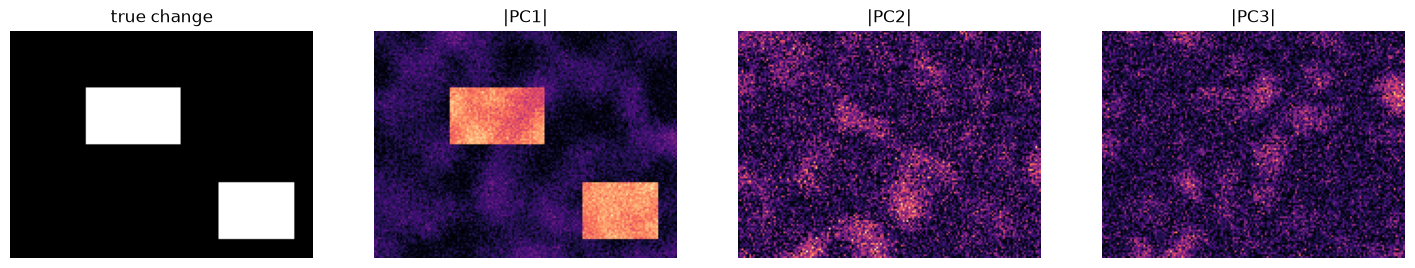

In [8]:
from scipy.ndimage import gaussian_filter
H, W = 120, 160
base = np.stack([gaussian_filter(rng.normal(size=(H, W)), 6) for _ in range(4)], -1) * 5 + 10
date1 = base + rng.normal(0, 0.3, base.shape)
date2 = 1.08 * base + 0.5 + rng.normal(0, 0.3, base.shape)                          # different illumination
change = np.zeros((H, W), bool); change[30:60, 40:90] = True; change[80:110, 110:150] = True
date2[change] += np.array([3, -2, 2.5, -3])                                       # new construction / clearing
stack = np.concatenate([date1, date2], -1).reshape(-1, 8)
pcs = PCA(8).fit_transform(StandardScaler().fit_transform(stack)).reshape(H, W, 8)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
axes[0].imshow(change, cmap="gray"); axes[0].set_title("true change")
for ax, k in zip(axes[1:], [0, 1, 2]):
    ax.imshow(np.abs(pcs[..., k]), cmap="magma"); ax.set_title(f"|PC{k + 1}|")
for ax in axes: ax.axis("off")
plt.show()

### Kernel PCA: non-linear structure
PCA finds only linear directions. Kernel PCA performs PCA in a kernel feature space (Day 32).

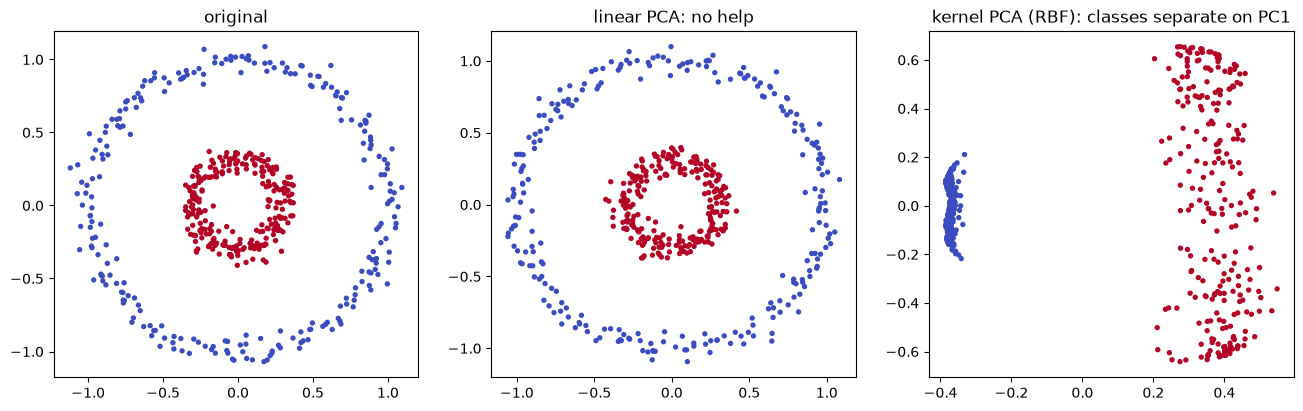

In [9]:
from sklearn.datasets import make_circles
Xc, yc = make_circles(500, factor=0.3, noise=0.05, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(*Xc.T, c=yc, cmap="coolwarm", s=8); axes[0].set_title("original")
axes[1].scatter(*PCA(2).fit_transform(Xc).T, c=yc, cmap="coolwarm", s=8); axes[1].set_title("linear PCA: no help")
axes[2].scatter(*KernelPCA(2, kernel="rbf", gamma=5).fit_transform(Xc).T, c=yc, cmap="coolwarm", s=8); axes[2].set_title("kernel PCA (RBF): classes separate on PC1")
plt.show()

### Incremental PCA for data that does not fit in memory

In [10]:
ipca = IncrementalPCA(n_components=10, batch_size=200)
for start in range(0, len(Xd), 200):
    ipca.partial_fit(Xd[start:start + 200])
print("incremental vs full PCA explained variance (first 3):", ipca.explained_variance_ratio_[:3].round(4), PCA(10).fit(Xd).explained_variance_ratio_[:3].round(4))

incremental vs full PCA explained variance (first 3): [0.1488 0.136  0.1178] [0.1489 0.1362 0.1179]


### Pitfalls
1. **Scale**: without standardisation, the feature with the largest units dominates PC1.
2. **High variance != important for prediction**: a small-variance direction can carry all the class information (then use PLS or LDA).
3. **Fit PCA on training data only** (inside the pipeline).
4. Components are hard to interpret when many features load on them.

In [11]:
Xv = np.c_[rng.normal(0, 10, 600), rng.normal(0, 0.5, 600)]; yv = (Xv[:, 1] > 0).astype(int)        # class info in the LOW-variance feature
from sklearn.linear_model import LogisticRegression
print("Logistic on PC1 only (unscaled):", cross_val_score(make_pipeline(PCA(1), LogisticRegression()), Xv, yv, cv=5).mean().round(3))
print("Logistic on both features      :", cross_val_score(LogisticRegression(), Xv, yv, cv=5).mean().round(3))

Logistic on PC1 only (unscaled): 0.545
Logistic on both features      : 0.99


## **Practice Problems**
1. Run PCA on the **unscaled** wine data. Which feature dominates PC1 and why?
2. Plot the reconstruction error of the clean digits against the number of components.
3. Use `PCA(n_components)` + `LogisticRegression` on the digits and tune n_components by CV.
4. *(Advanced)* Implement PCA via **power iteration**: repeatedly multiply a random vector by the covariance matrix and normalise; compare with the first eigenvector.

top loading on PC1 (unscaled): proline -> proline has the largest variance (hundreds)


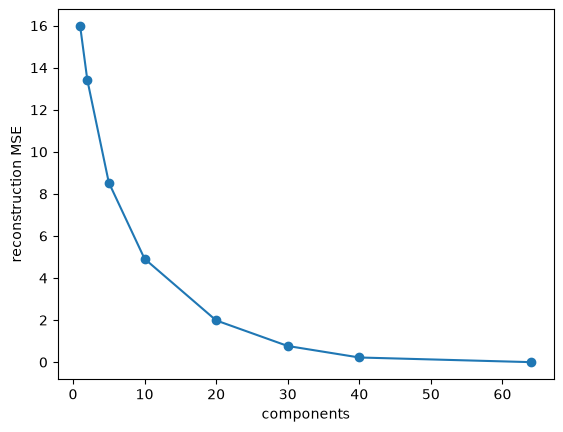

best n_components: {'pca__n_components': 40} accuracy 0.914
power iteration matches the first eigenvector: True


In [12]:
# Solution 1
raw = PCA(2).fit(Xw); print("top loading on PC1 (unscaled):", names[np.argmax(np.abs(raw.components_[0]))], "-> proline has the largest variance (hundreds)")
# Solution 2
errs = [np.mean((Xd - PCA(k).fit(Xd).inverse_transform(PCA(k).fit(Xd).transform(Xd))) ** 2) for k in [1, 2, 5, 10, 20, 30, 40, 64]]
plt.plot([1, 2, 5, 10, 20, 30, 40, 64], errs, "o-"); plt.xlabel("components"); plt.ylabel("reconstruction MSE"); plt.show()
# Solution 3
from sklearn.model_selection import GridSearchCV
g = GridSearchCV(make_pipeline(StandardScaler(), PCA(), LogisticRegression(max_iter=3000)), {"pca__n_components": [5, 10, 20, 30, 40]}, cv=5).fit(Xd, yd)
print("best n_components:", g.best_params_, "accuracy", round(g.best_score_, 3))
# Solution 4
v = rng.normal(size=13)
for _ in range(200):
    v = C @ v; v /= np.linalg.norm(v)
print("power iteration matches the first eigenvector:", np.allclose(np.abs(v), np.abs(evecs[:, 0]), atol=1e-6))

## **Key References**
- Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559-572.
- Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology*, 24(6), 417-441.
- Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374(2065), 20150202.
- Wold, S., Sjostrom, M., & Eriksson, L. (2001). PLS-regression: a basic tool of chemometrics. *Chemometrics and Intelligent Laboratory Systems*, 58(2), 109-130.
- Scholkopf, B., Smola, A., & Muller, K.-R. (1998). Nonlinear component analysis as a kernel eigenvalue problem. *Neural Computation*, 10(5), 1299-1319.
- Byrne, G. F., Crapper, P. F., & Mayo, K. K. (1980). Monitoring land-cover change by principal component analysis of multitemporal Landsat data. *Remote Sensing of Environment*, 10(3), 175-184.